In [3]:
import pandas as pd

df = pd.read_csv('netflix_titles.csv')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s572,Movie,Wild Storm,NaN,NaN,Mexico,"November 2, 2022",2008,R,104 min,Sci-Fi & Fantasy,An emotional journey that blends humor and hea...
1,s1091,Movie,Sacred River,NaN,"Priya Tanaka, James Sharma",India,"March 22, 2018",2014,TV-MA,108 min,Independent Movies,An emotional journey that blends humor and hea...
2,s775,TV Show,Shattered Promise,Meera Johnson,"Fatima Kim, Elena Nguyen, Grace Silva",United States,"June 10, 2017",2009,TV-14,5 Seasons,Romantic TV Shows,A heartfelt look at ordinary lives caught in e...
3,s405,TV Show,Dark Echoes,NaN,"Wei Costa, Elena Park, Aiko Tanaka, Diego Silva",India,"November 21, 2020",2007,TV-14,1 Season,Romantic TV Shows,"Set against a vivid backdrop, this tells a tal..."
4,s76,Movie,Shattered Journey,Aarav Cohen,NaN,South Korea,"March 24, 2019",2015,TV-MA,166 min,"Sci-Fi & Fantasy, Dramas","Set against a vivid backdrop, this tells a tal..."


In [4]:
print("Shape of data", df.shape)
df.info()

Shape of data (1265, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1265 entries, 0 to 1264
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       1265 non-null   object
 1   type          1265 non-null   object
 2   title         1265 non-null   object
 3   director      689 non-null    object
 4   cast          894 non-null    object
 5   country       1153 non-null   object
 6   date_added    1265 non-null   object
 7   release_year  1265 non-null   int64 
 8   rating        1265 non-null   object
 9   duration      1265 non-null   object
 10  listed_in     1265 non-null   object
 11  description   1265 non-null   object
dtypes: int64(1), object(11)
memory usage: 118.7+ KB


In [6]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,576
cast,371
country,112
date_added,0
release_year,0
rating,0
duration,0


In [10]:
df.duplicated().sum()

np.int64(15)

In [11]:
## Step 1 Remove duplicate

In [12]:
df= df.drop_duplicates()
print("Shape of data", df.shape)   # Duplicates are removed #

Shape of data (1250, 12)


In [13]:
## Step 2: Cleaning Missing values

In [15]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

## We need to also fill those null values with "Unknown" ##

df['director'] = df['director'].replace('', 'Unknown')
df['cast']= df['cast'].replace('', 'Unknown')
df['country'] = df['country'].replace('', 'Unknown')

In [16]:
df.isnull().sum()


,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [17]:
## Step 3: Now removing extra spaces and fixing lowercase

In [18]:
df['country'] = df['country'].str.strip()
df['country'] = df['country'].str.title()

In [21]:
df['country'].unique()   #To check the consistency of the data

array(['Mexico', 'India', 'United States', 'South Korea', 'Germany',
       'Australia', 'France', 'Brazil', 'Italy', 'Unknown', 'Spain',
       'Japan', 'United Kingdom', 'Canada', 'Nigeria'], dtype=object)

In [22]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [24]:
df['country'].unique()

array(['Mexico', 'India', 'United States', 'South Korea', 'Germany',
       'Australia', 'France', 'Brazil', 'Italy', 'Unknown', 'Spain',
       'Japan', 'United Kingdom', 'Canada', 'Nigeria'], dtype=object)

In [25]:
## Step 4: Now converting Duration column into numbers,
## for calculation.

In [33]:
df['duration_minutes'] = df[df['type'] == 'Movie']['duration'].str.replace('min','', regex=False).astype(float)
df['duration_seasons']= df[df['type'] == 'TV Show']['duration'].str.extract(r'(\d+)').astype(float)
df[['type', 'duration', 'duration_minutes', 'duration_seasons', ]].head(10)

,type,duration,duration_minutes,duration_seasons
0,Movie,104 min,104.0,NaN
1,Movie,108 min,108.0,NaN
2,TV Show,5 Seasons,NaN,5.0
3,TV Show,1 Season,NaN,1.0
4,Movie,166 min,166.0,NaN
5,TV Show,1 Season,NaN,1.0
6,TV Show,5 Seasons,NaN,5.0
7,Movie,124 min,124.0,NaN
8,Movie,88 min,88.0,NaN
9,Movie,155 min,155.0,NaN


In [34]:
## Converting date in datetime

In [39]:
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2022-11-02,2022,November
1,2018-03-22,2018,March
2,2017-06-10,2017,June
3,2020-11-21,2020,November
4,2019-03-24,2019,March


In [40]:
## Step 5: Exploratory Data Analysis (EDA)


In [42]:
## Q> How many movies and series are Available.

df['type'].value_counts()

,count
type,
Movie,872
TV Show,378


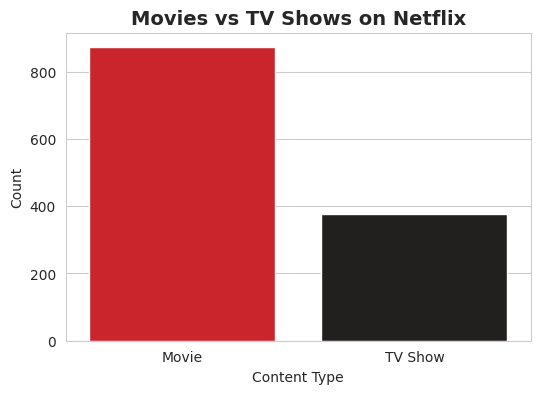

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type',hue = 'type', palette=['#E50914', '#221f1f'], legend=False)
plt.title('Movies vs TV Shows on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

In [46]:
## Q> How content grew in netflix Year to year??

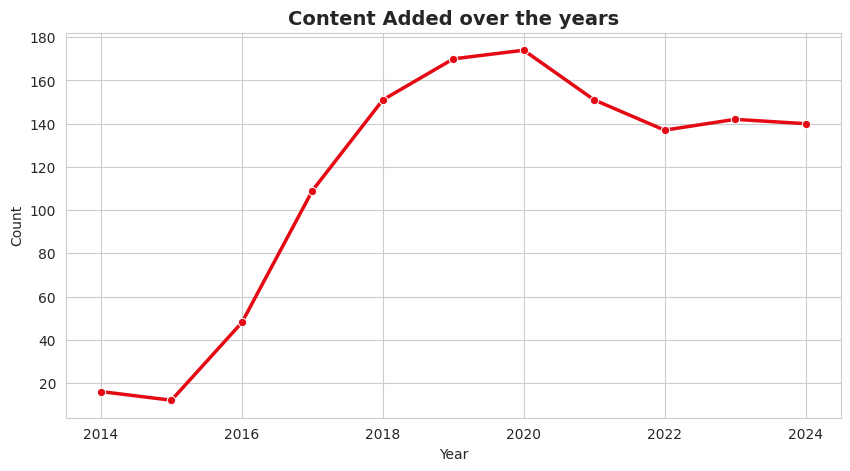

In [52]:
plt.figure(figsize= (10,5))
yearly_content = df['year_added'].value_counts().sort_index()
sns.lineplot(x = yearly_content.index, y = yearly_content.values, marker = 'o', color ='#E50914', linewidth = 2.5 )
plt.title('Content Added over the years', fontsize = 14, fontweight = 'bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


In [53]:
## Q> Most popular genre



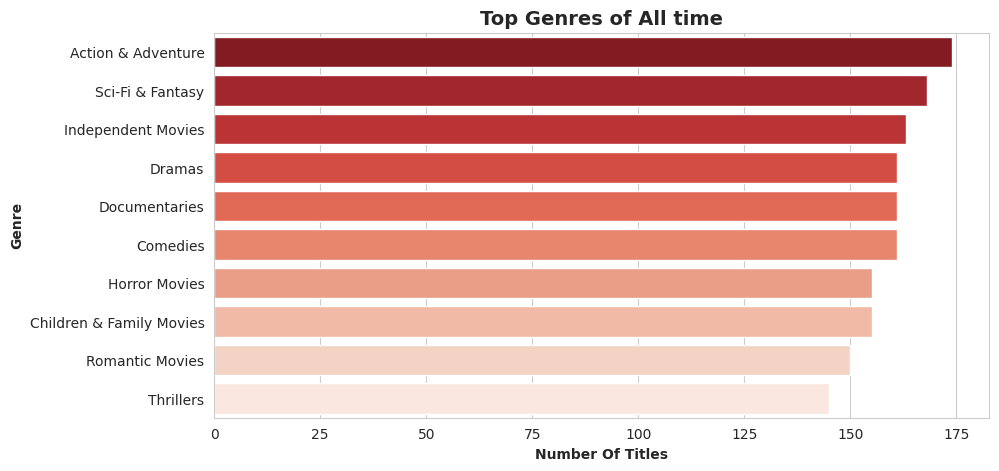

In [67]:
all_genres = df['listed_in'].str.split(', ').explode()

plt.figure(figsize = (10,5))
top_genres = all_genres.value_counts().head(10)

sns.barplot(x = top_genres.values, y = top_genres.index,hue = top_genres.index, palette = 'Reds_r', legend=False)
plt.title('Top Genres of All time', fontsize = 14, fontweight = 'bold')
plt.xlabel('Number Of Titles', fontweight='bold')
plt.ylabel('Genre', fontweight = 'bold')
plt.show()

In [68]:
## Insights>> That the top 3-4 genres are very close in counts,
# and the others are also performing well.
# This means all the categories are content balanced.

In [69]:
## Q> Top countries who makes more content

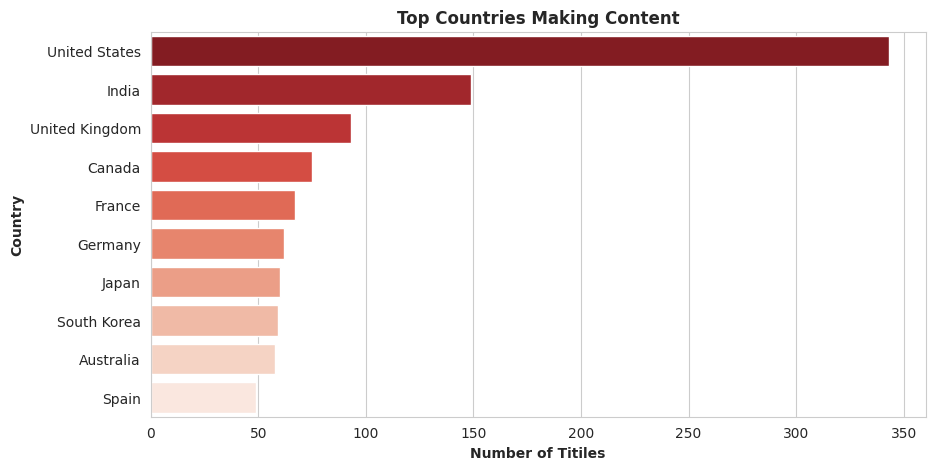

In [73]:
plt.figure(figsize = (10,5))
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(10)
sns.barplot(x = top_countries.values, y = top_countries.index, hue = top_countries.index,palette = 'Reds_r', legend=False)
plt.title('Top Countries Making Content', fontweight = 'bold')
plt.xlabel('Number of Titiles', fontweight='bold')
plt.ylabel('Country', fontweight='bold')
plt.show()

In [74]:
## Q> Rating distribution

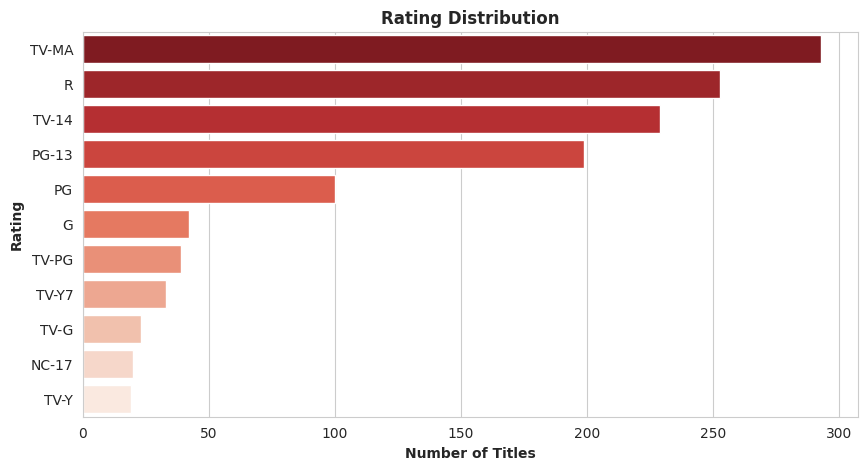

In [76]:
plt.figure(figsize = (10,5))
rating_counts = df['rating'].value_counts()
sns.barplot(x = rating_counts.values, y = rating_counts.index, hue = rating_counts.index, palette = "Reds_r", legend = False)
plt.title('Rating Distribution', fontweight = 'bold')
plt.xlabel('Number of Titles', fontweight = 'bold')
plt.ylabel('Rating', fontweight = 'bold')
plt.show()

In [77]:
## INSIGHTS>> As we can see, TV-MA has around 290 titles
# and after that R, TV-14 are in top 3,
#So we can say that netflix'library is Adult-Audience-Focused.

In [78]:
## Q> Movies's Average durations

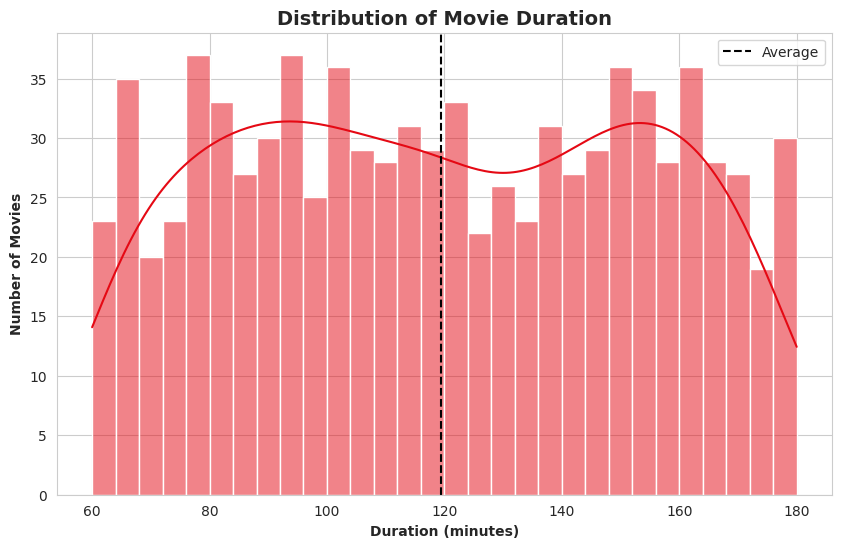

Average movie duration: 119.3 minutes


In [79]:
plt.figure(figsize=(10,6))
sns.histplot(df[df['type']=='Movie']['duration_minutes'], bins=30, color='#E50914', kde=True)
plt.title('Distribution of Movie Duration', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)', fontweight='bold')
plt.ylabel('Number of Movies', fontweight='bold')
plt.axvline(df[df['type']=='Movie']['duration_minutes'].mean(), color='black', linestyle='--', label='Average')
plt.legend()
plt.show()

print("Average movie duration:", round(df[df['type']=='Movie']['duration_minutes'].mean(), 1), "minutes")

In [80]:
## Q> How many seasons are in TV Shows usually??


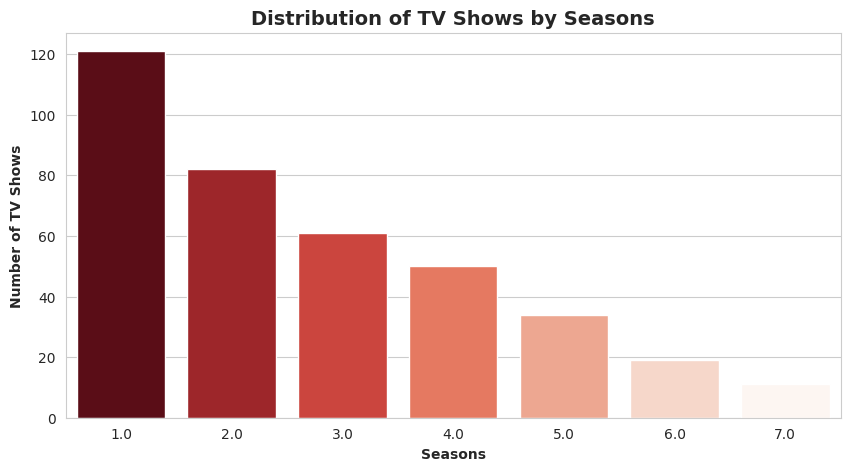

In [84]:
plt.figure(figsize = (10,5))
season_counts = df[df['type'] == 'TV Show']['duration_seasons'].value_counts().sort_index()
sns.barplot( x= season_counts.index, y = season_counts.values, hue=season_counts.index, palette='Reds_r', legend=False)
plt.title('Distribution of TV Shows by Seasons', fontsize = 14, fontweight= 'bold')
plt.xlabel('Seasons', fontweight = 'bold')
plt.ylabel('Number of TV Shows', fontweight = 'bold')
plt.show()



In [85]:
## Q> Relationship between Genre and Content-Type

/tmp/ipykernel_1705/2700636224.py:9: UserWarning: The palette list has more values (2) than needed (1), which may not be intended.
  sns.countplot(data=filtered, y='listed_in', hue='type', palette=['#E50914', '#221f1f'])


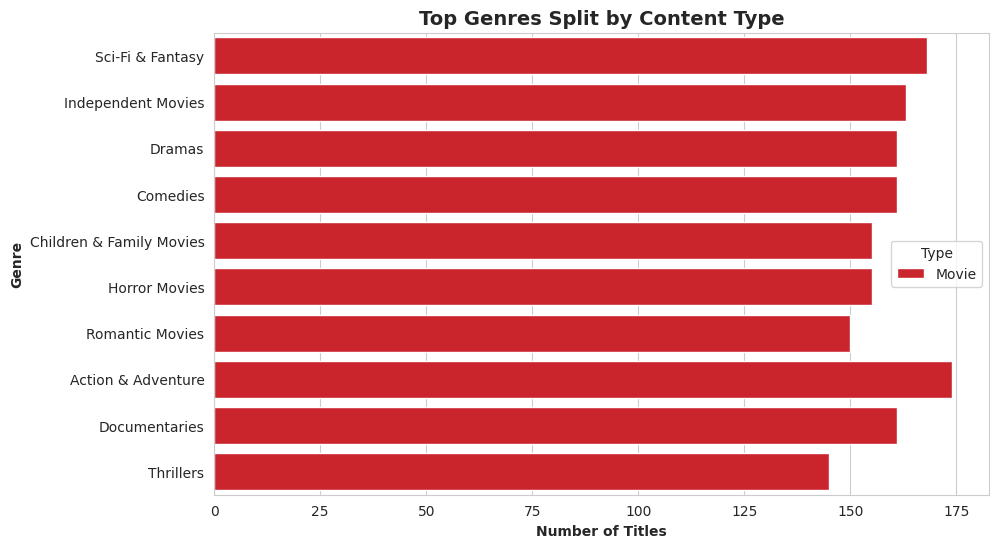

In [93]:
genre_type_df = df[['type', 'listed_in']].copy()
genre_type_df['listed_in'] = genre_type_df['listed_in'].str.split(', ')
genre_type_df = genre_type_df.explode('listed_in')

top_10_genres_list = genre_type_df['listed_in'].value_counts().head(10).index
filtered = genre_type_df[genre_type_df['listed_in'].isin(top_10_genres_list)]

plt.figure(figsize=(10,6))
sns.countplot(data=filtered, y='listed_in', hue='type', palette=['#E50914', '#221f1f'])
plt.title('Top Genres Split by Content Type', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles', fontweight='bold')
plt.ylabel('Genre', fontweight='bold')
plt.legend(title='Type')
plt.show()

In [94]:
## Making Two charts both for Movies and TV Shows

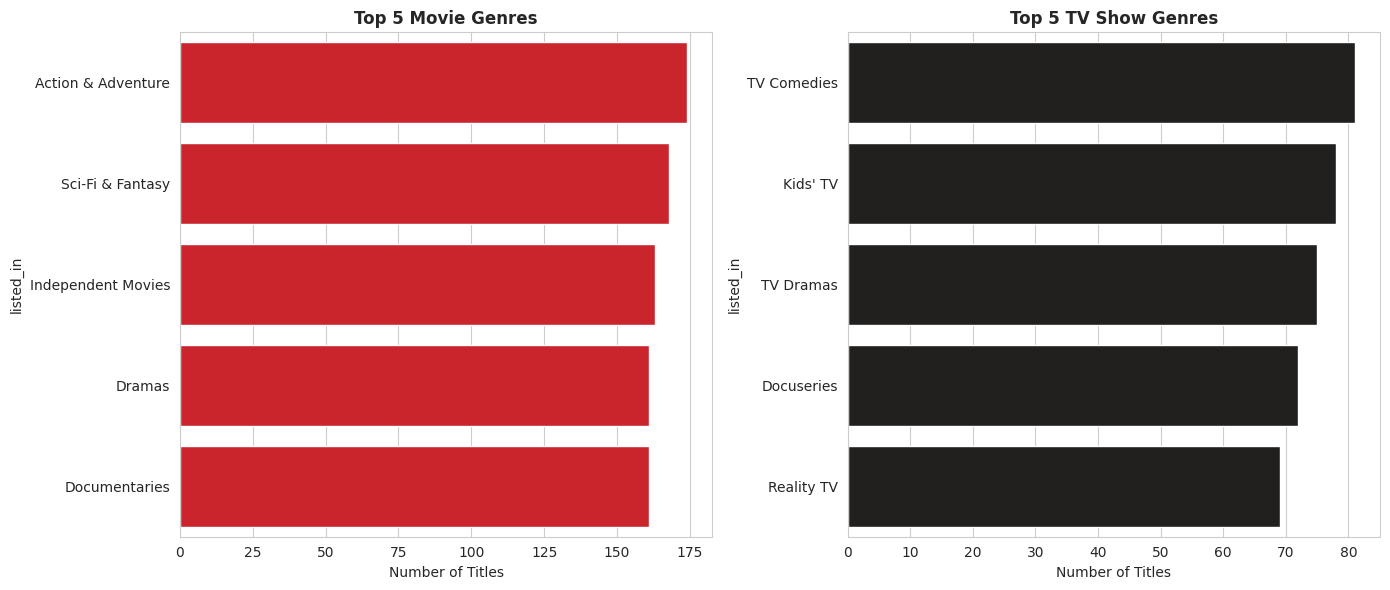

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

movie_genres = genre_type_df[genre_type_df['type'] == 'Movie']['listed_in'].value_counts().head(5)
tv_genres = genre_type_df[genre_type_df['type'] == 'TV Show']['listed_in'].value_counts().head(5)

sns.barplot(x = movie_genres.values, y = movie_genres.index, color='#E50914', ax=axes[0])
axes[0].set_title('Top 5 Movie Genres', fontweight='bold')
axes[0].set_xlabel('Number of Titles')

sns.barplot(x=tv_genres.values, y=tv_genres.index, color='#221f1f', ax=axes[1])
axes[1].set_title('Top 5 TV Show Genres', fontweight='bold')
axes[1].set_xlabel('Number of Titles')

plt.tight_layout()
plt.show()

In [101]:
## Q>  Seasonal Pattern

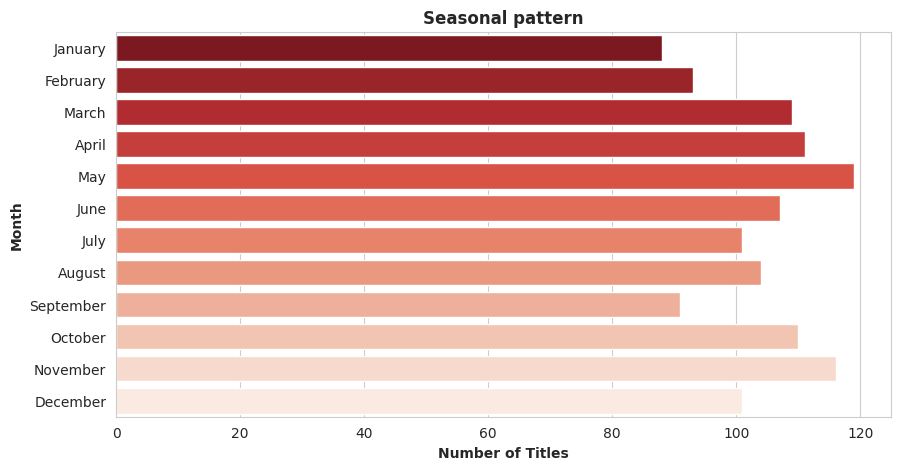

In [105]:
plt.figure(figsize = (10,5))

month_order = ['January', 'February', 'March','April','May','June','July','August', 'September','October', 'November', 'December']
month_counts = df['month_added'].value_counts().reindex(month_order)

sns.barplot(x=month_counts.values, y = month_counts.index, hue = month_counts.index, palette= 'Reds_r', legend=False)
plt.title('Seasonal pattern', fontweight = 'bold')
plt.xlabel('Number of Titles', fontweight = 'bold')
plt.ylabel('Month', fontweight = 'bold')
plt.show()


In [106]:
## Q> Countries Vs Genre HeatMap

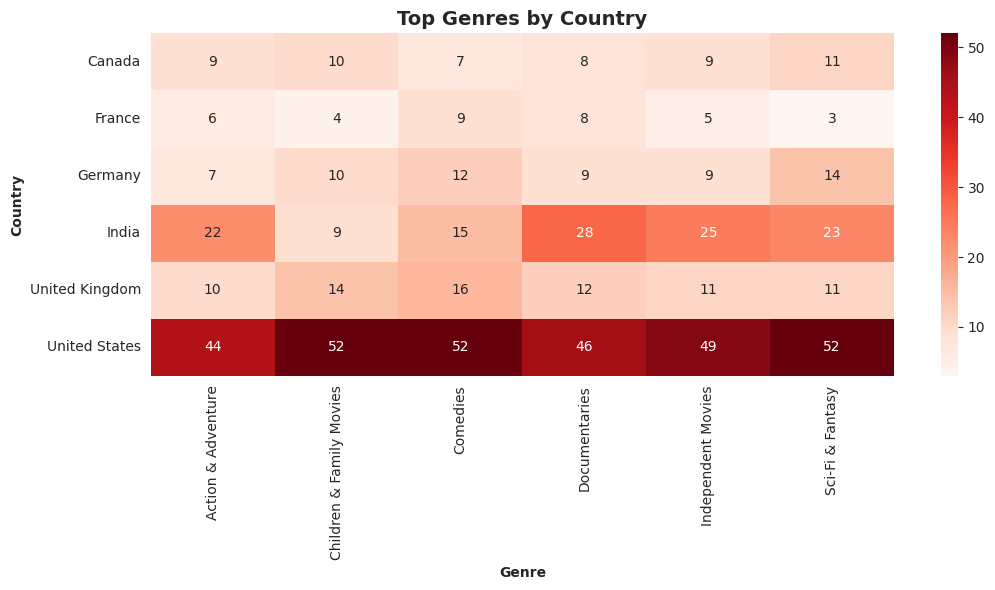

In [107]:
top_countries_list = df[df['country']!='Unknown']['country'].value_counts().head(6).index
country_genre_df = df[df['country'].isin(top_countries_list)][['country', 'listed_in']].copy()
country_genre_df['listed_in'] = country_genre_df['listed_in'].str.split(', ')
country_genre_df = country_genre_df.explode('listed_in')

top_genres_overall = country_genre_df['listed_in'].value_counts().head(6).index
country_genre_df = country_genre_df[country_genre_df['listed_in'].isin(top_genres_overall)]

pivot = country_genre_df.pivot_table(index='country', columns='listed_in', aggfunc='size', fill_value=0)

plt.figure(figsize=(11,6))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds')
plt.title('Top Genres by Country', fontsize=14, fontweight='bold')
plt.xlabel('Genre', fontweight='bold')
plt.ylabel('Country', fontweight='bold')
plt.tight_layout()
plt.show()

## Key Insights

- **Content mix**: Movies dominate the platform (872 titles, ~70%) compared to TV Shows (378 titles, ~30%).
- **Growth trend**: Content additions grew sharply from 2016-2020 (Netflix's major expansion era), then plateaued around 140-175 titles/year from 2020 onward.
- **Top genres overall**: Action & Adventure, Sci-Fi & Fantasy, and Independent Movies lead the catalog.
- **Genre by type**: Movies lean toward Action & Adventure, while TV Shows lean toward Comedies — showing different content strategies per format.
- **Geographic concentration**: United States produces the most content by far, followed by India, UK, and Canada. The heatmap confirms the US leads in every individual genre category.
- **Rating skew**: The catalog is mature-audience focused — TV-MA, R, and TV-14 are the top three ratings, well ahead of family/kids ratings.
- **TV Show longevity**: Most TV shows (about 120 of 378) run for only 1 season, with a sharp long-tail drop-off — very few shows reach 5+ seasons.
- **Average movie length**: 119.3 minutes, fairly evenly distributed across the 60-180 minute range.